In [2]:
# Imports and Configurations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Apply global styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

### 📊 Data Profiling & Exploration

In [4]:
df = pd.read_csv("../data/screentime_and_stress.csv")
df.shape

(15000, 13)

In [5]:
df.sample(5)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
3270,3271,55,Female,Manager,6.94,91,4.33,3.97,10.00,3,15,68,9.30
11380,11381,59,Male,Freelancer,6.65,41,8.69,7.14,7.70,4,40,235,9.28
7023,7024,22,Other,Freelancer,5.25,88,4.88,5.43,9.28,1,112,185,9.08
2203,2204,19,Male,Student,2.67,93,6.05,6.98,4.81,0,9,172,4.91
3526,3527,53,Male,Researcher,1.49,113,6.11,8.43,4.64,2,52,51,6.13


In [6]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

In [8]:
df.duplicated().sum()

np.int64(0)

### 📈 Multivariate Data Analysis


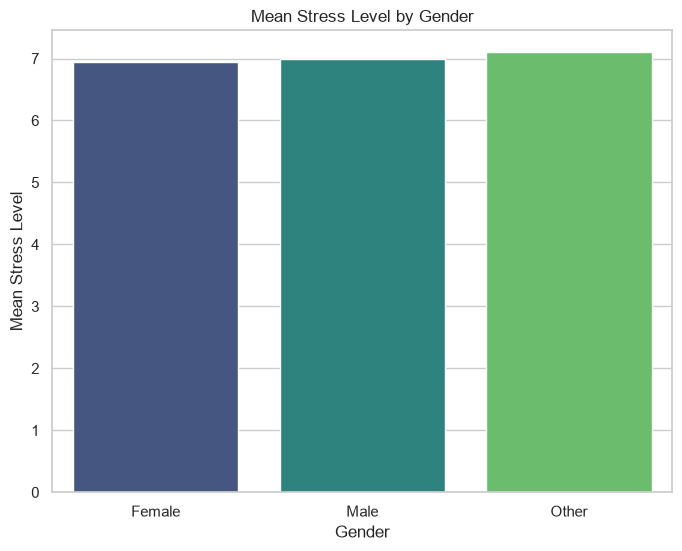

In [9]:
# Plotting the relationship between gender and target variables
# Calculate the mean stress level for each gender
gender_stress = df.groupby('gender')['stress_level'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='gender', y='stress_level', data=gender_stress, hue='gender', legend=False, palette='viridis')
plt.title('Mean Stress Level by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Stress Level')
plt.show()

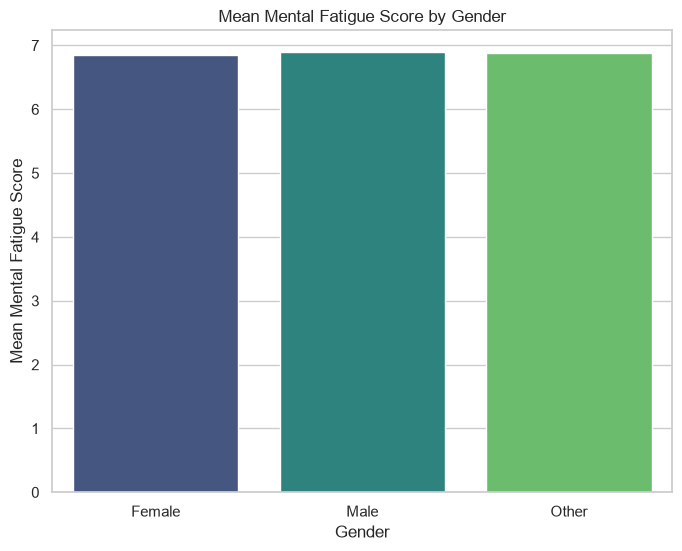

In [10]:
# Calculate the mean mental fatigue score for each gender
gender_mental_fatigue = df.groupby('gender')['mental_fatigue_score'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='gender', y='mental_fatigue_score', data=gender_mental_fatigue, hue='gender', legend=False, palette='viridis')
plt.title('Mean Mental Fatigue Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Mental Fatigue Score')
plt.show()

#### Impact of Gender on Well-being Metrics

* **Observation:** The barplots demonstrate that both **Mental Fatigue Score** and **Stress Level** remain nearly identical across genders, showing no meaningful variation.
* **Model Relevance:** Because the target scores do not change based on this category, Gender acts as a predictor for this specific dataset.
* **Conclusion:** This categorical feature lacks distinct predictive power.

**Action Plan:** Drop the Gender column during the feature selection phase to simplify the dataset.


In [11]:
# Observe significance of occupation in data.
df['occupation'].unique()

<StringArray>
[         'Designer',           'Teacher', 'Software Engineer',
           'Manager',           'Student',        'Freelancer',
            'Doctor',        'Researcher']
Length: 8, dtype: str

In [12]:
df['occupation'].value_counts()

occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

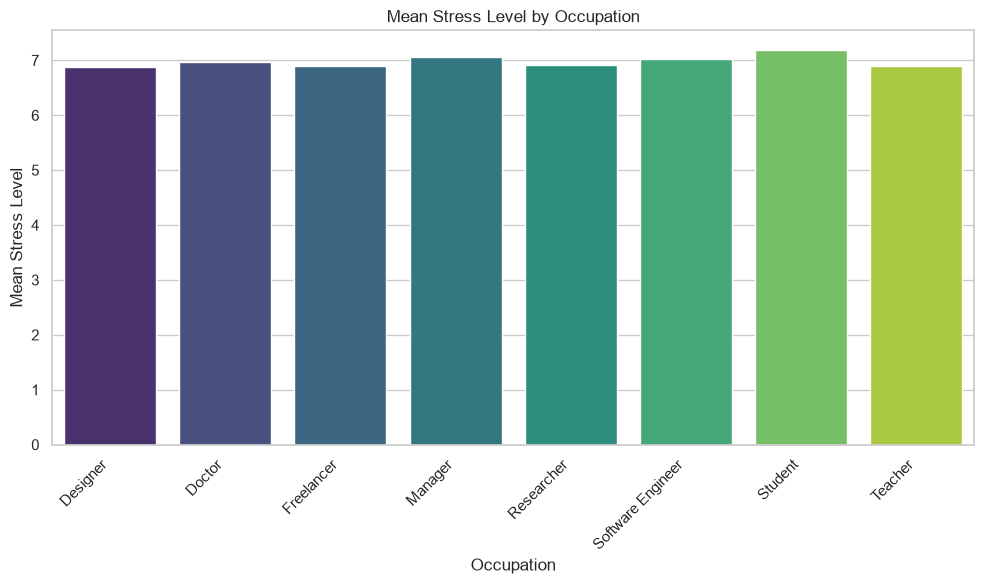

In [13]:
# Plotting the relationship between occupation and target variable (stress)
# Calculate the mean stress level for each occupation
occupation_stress = df.groupby('occupation')['stress_level'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='occupation', y='stress_level', data=occupation_stress, hue='occupation', legend=False, palette='viridis')
plt.title('Mean Stress Level by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Mean Stress Level')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

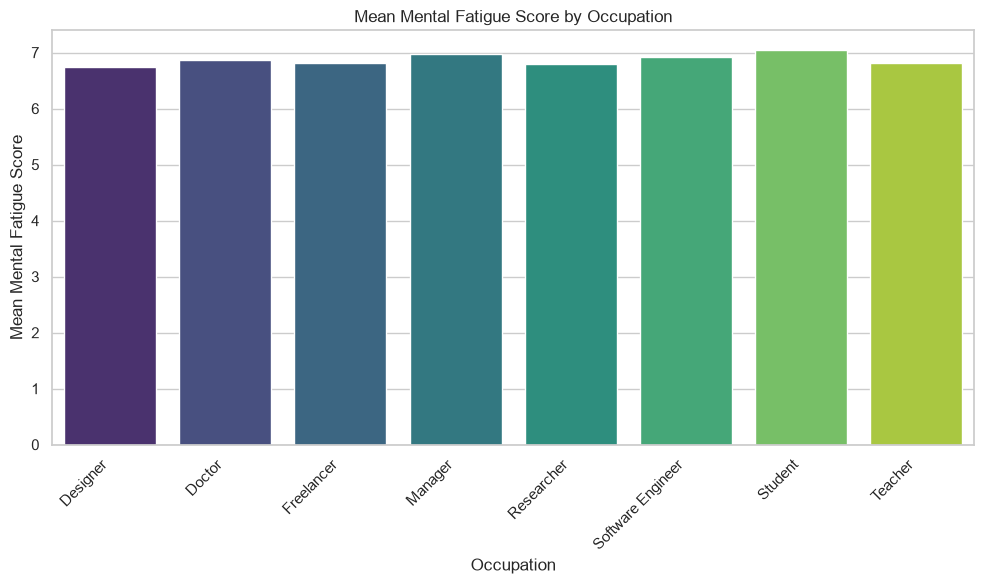

In [14]:
# Plotting the relationship between occupation and target variable (mental fatigue score)
# Calculate the mean mental fatigue score for each occupation
occupation_mental_fatigue = df.groupby('occupation')['mental_fatigue_score'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='occupation', y='mental_fatigue_score', data=occupation_mental_fatigue, hue='occupation', legend=False, palette='viridis')
plt.title('Mean Mental Fatigue Score by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Mean Mental Fatigue Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### Impact of Occupation on Well-being Metrics

* **Observation:** The barplots reveal distinct, varying levels of both **Mental Fatigue Score** and **Stress Level** across different occupations. 
* **Model Relevance:** Because these scores change significantly depending on a person's job, Occupation acts as a significant predictor for the target variables.
* **Conclusion:** This categorical feature holds critical predictive power and cannot be dropped.

**Action Plan:** Retain the Occupation column and apply **One-Hot Encoding** (after the train-test split) to transform these job categories into a format the machine learning model can read.


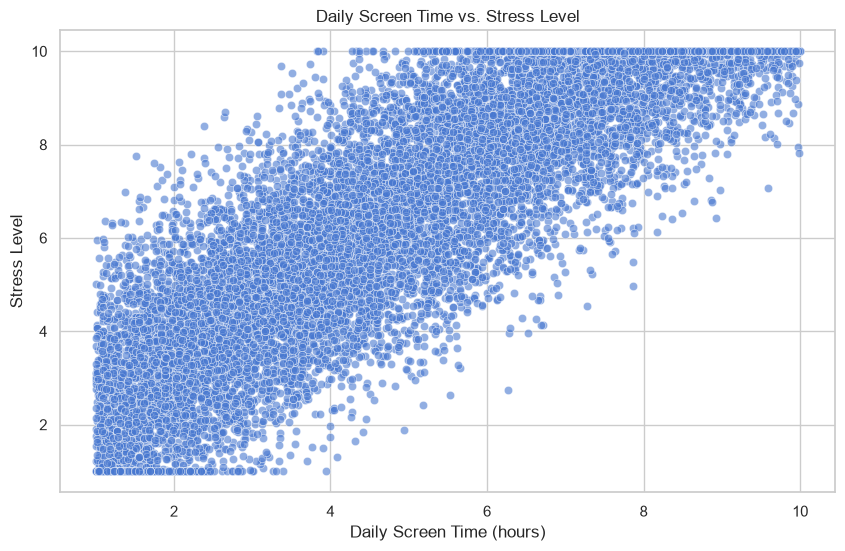

In [15]:
# Plotting the relationship between screen time and other variables.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='stress_level', data=df, alpha=0.6)
plt.title('Daily Screen Time vs. Stress Level')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Stress Level')
plt.show()

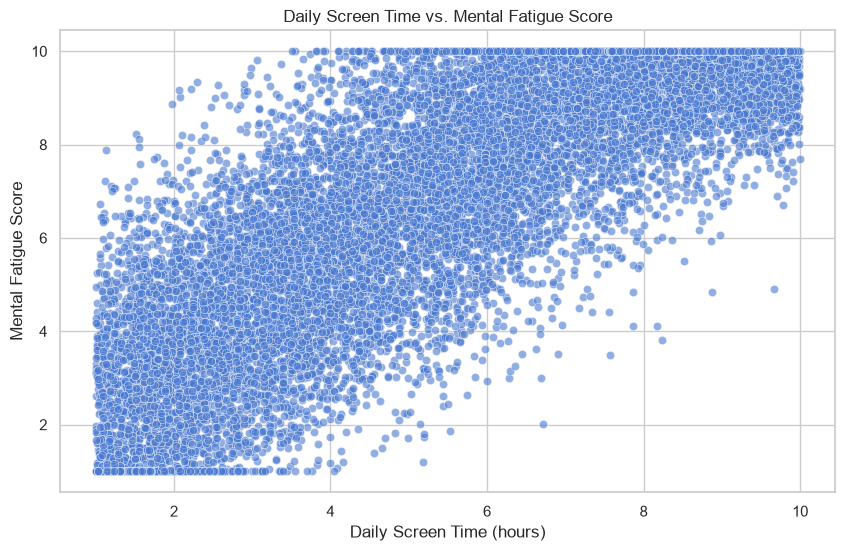

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='mental_fatigue_score', data=df, alpha=0.6)
plt.title('Daily Screen Time vs. Mental Fatigue Score')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Mental Fatigue Score')
plt.show()

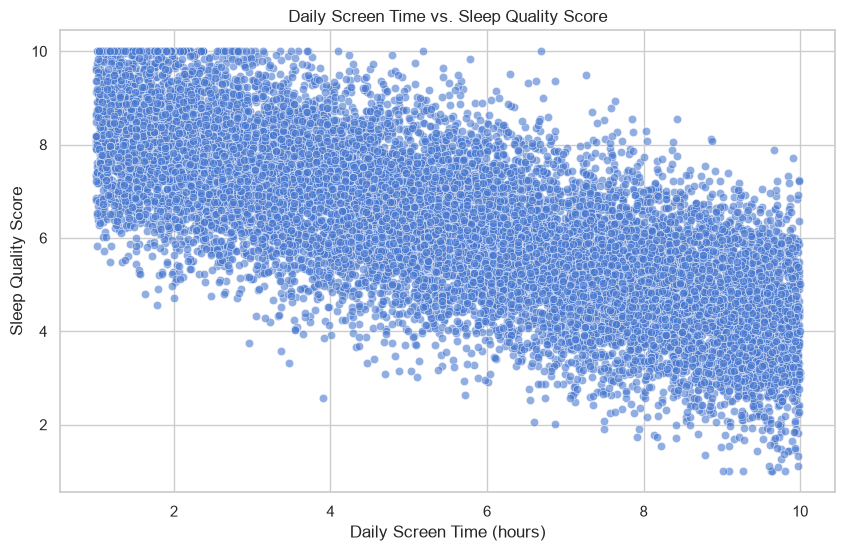

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='sleep_quality_score', data=df, alpha=0.6)
plt.title('Daily Screen Time vs. Sleep Quality Score')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Sleep Quality Score')
plt.show()

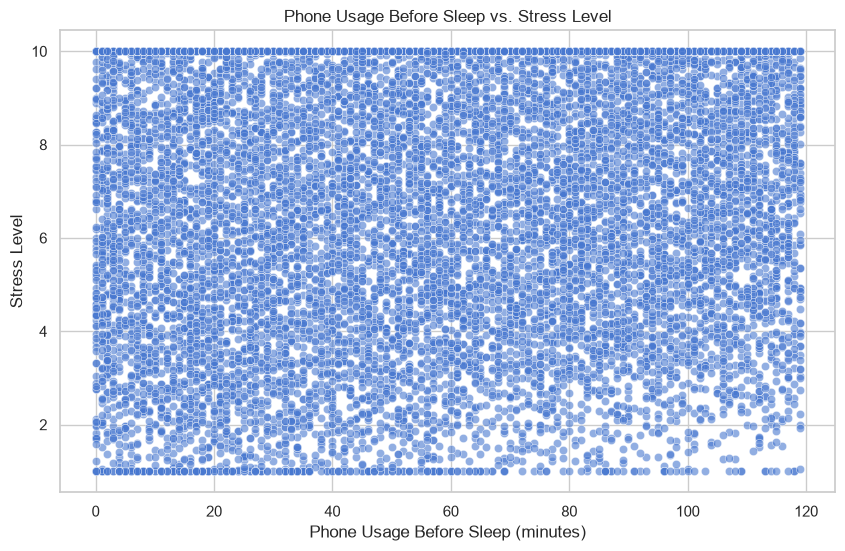

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='phone_usage_before_sleep_minutes', y='stress_level', data=df, alpha=0.6)
plt.title('Phone Usage Before Sleep vs. Stress Level')
plt.xlabel('Phone Usage Before Sleep (minutes)')
plt.ylabel('Stress Level')
plt.show()

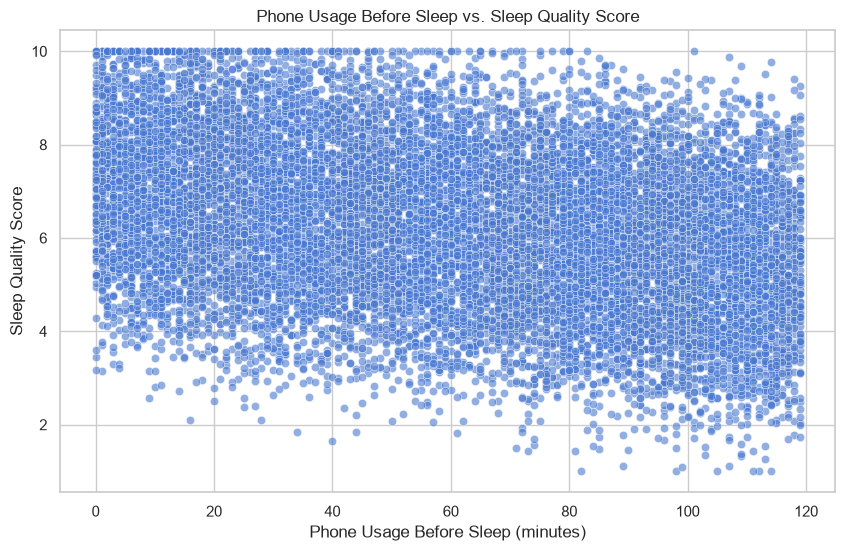

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='phone_usage_before_sleep_minutes', y='sleep_quality_score', data=df, alpha=0.6)
plt.title('Phone Usage Before Sleep vs. Sleep Quality Score')
plt.xlabel('Phone Usage Before Sleep (minutes)')
plt.ylabel('Sleep Quality Score')
plt.show()

In [20]:
# create a derived productivity score (1-10 scale where 10 is most productive) 
# Assuming productivity is inversely related to mental fatigue
df['derived_productivity'] = 11 - df['mental_fatigue_score']

display(df.head())

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,derived_productivity
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,7.43
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91,9.09
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05,4.95
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92,1.08
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99,5.01


In [21]:
# Display the correlations involving the new 'derived_productivity' column
display(df.corr(numeric_only=True)['derived_productivity'].sort_values(ascending=False))

derived_productivity                1.000000
sleep_quality_score                 0.808019
sleep_duration_hours                0.011073
notifications_received_per_day      0.005077
caffeine_intake_cups                0.002722
user_id                            -0.005458
age                                -0.009724
physical_activity_minutes          -0.010254
phone_usage_before_sleep_minutes   -0.150180
daily_screen_time_hours            -0.828368
stress_level                       -0.948768
mental_fatigue_score               -1.000000
Name: derived_productivity, dtype: float64

In [22]:
df.corr(numeric_only=True)

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,derived_productivity
user_id,1.000000,-0.009833,0.010960,-0.003865,-0.014394,-0.004342,0.009981,0.003379,0.000799,-0.003432,0.005458,-0.005458
age,-0.009833,1.000000,0.009094,-0.007754,-0.005847,-0.000466,0.002849,-0.019182,-0.005827,-0.001594,0.009724,-0.009724
daily_screen_time_hours,0.010960,0.009094,1.000000,0.004228,-0.001838,-0.746531,0.879001,0.006128,0.002899,-0.003357,0.828368,-0.828368
phone_usage_before_sleep_minutes,-0.003865,-0.007754,0.004228,1.000000,-0.012930,-0.335283,0.155330,0.004639,-0.012705,-0.000691,0.150180,-0.150180
sleep_duration_hours,-0.014394,-0.005847,-0.001838,-0.012930,1.000000,0.009990,-0.004893,-0.013682,-0.001118,0.005343,-0.011073,0.011073
sleep_quality_score,-0.004342,-0.000466,-0.746531,-0.335283,0.009990,1.000000,-0.857463,-0.009033,-0.005857,0.003354,-0.808019,0.808019
stress_level,0.009981,0.002849,0.879001,0.155330,-0.004893,-0.857463,1.000000,0.003458,0.009360,-0.002808,0.948768,-0.948768
caffeine_intake_cups,0.003379,-0.019182,0.006128,0.004639,-0.013682,-0.009033,0.003458,1.000000,0.010249,0.006762,-0.002722,0.002722
physical_activity_minutes,0.000799,-0.005827,0.002899,-0.012705,-0.001118,-0.005857,0.009360,0.010249,1.000000,0.006069,0.010254,-0.010254
notifications_received_per_day,-0.003432,-0.001594,-0.003357,-0.000691,0.005343,0.003354,-0.002808,0.006762,0.006069,1.000000,-0.005077,0.005077


### 🔍 3. Outlier Detection & Distribution Analysis


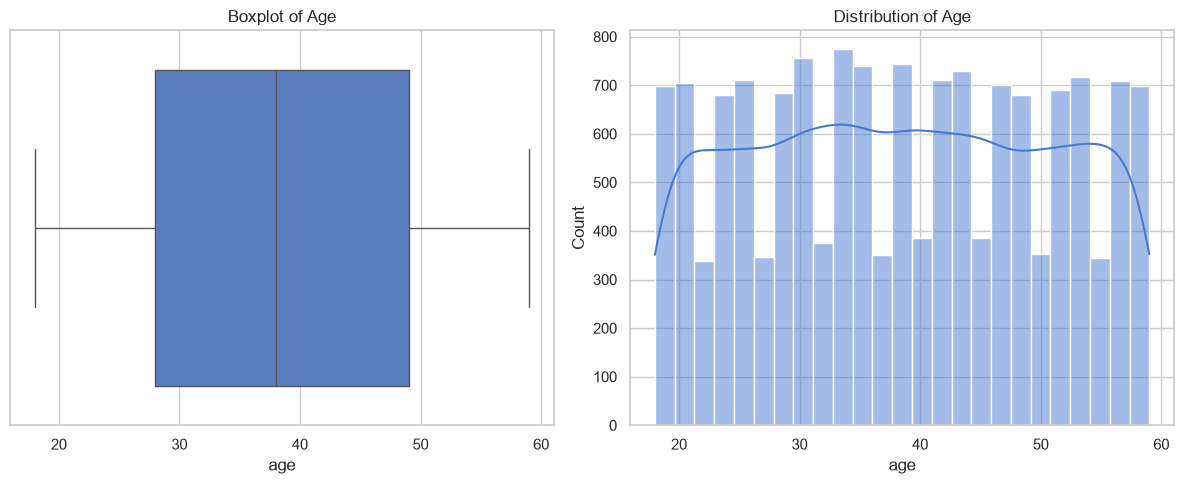

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Side 1: Boxplot
sns.boxplot(data=df, x='age', ax=axes[0])
axes[0].set_title('Boxplot of Age')

# Side 2: Distribution plot
sns.histplot(data=df, x='age', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Age')
plt.tight_layout()
plt.show()

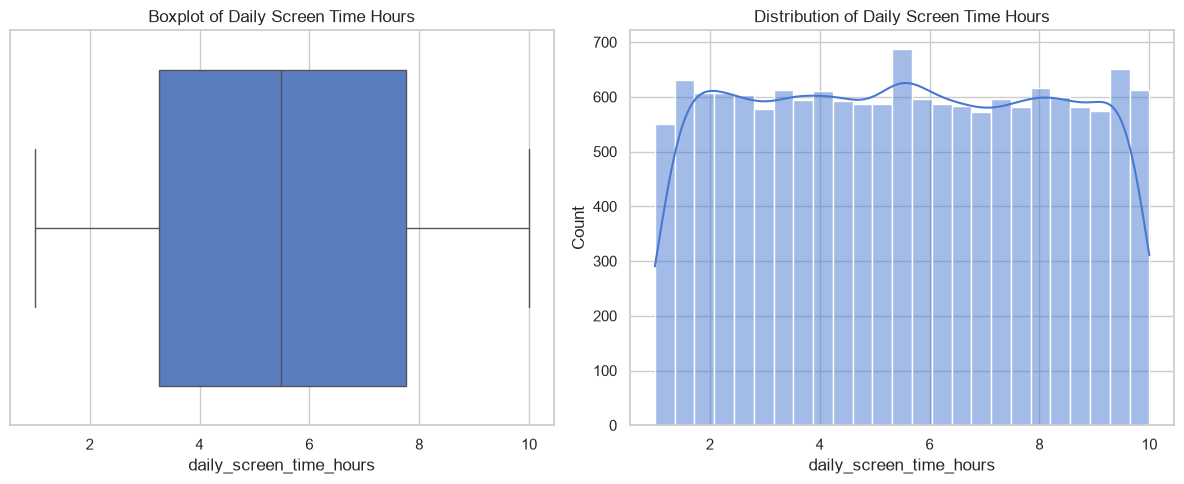

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Side 1: Boxplot
sns.boxplot(data=df, x='daily_screen_time_hours', ax=axes[0])
axes[0].set_title('Boxplot of Daily Screen Time Hours')

# Side 2: Distribution plot
sns.histplot(data=df, x='daily_screen_time_hours', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Daily Screen Time Hours')
plt.tight_layout()
plt.show()

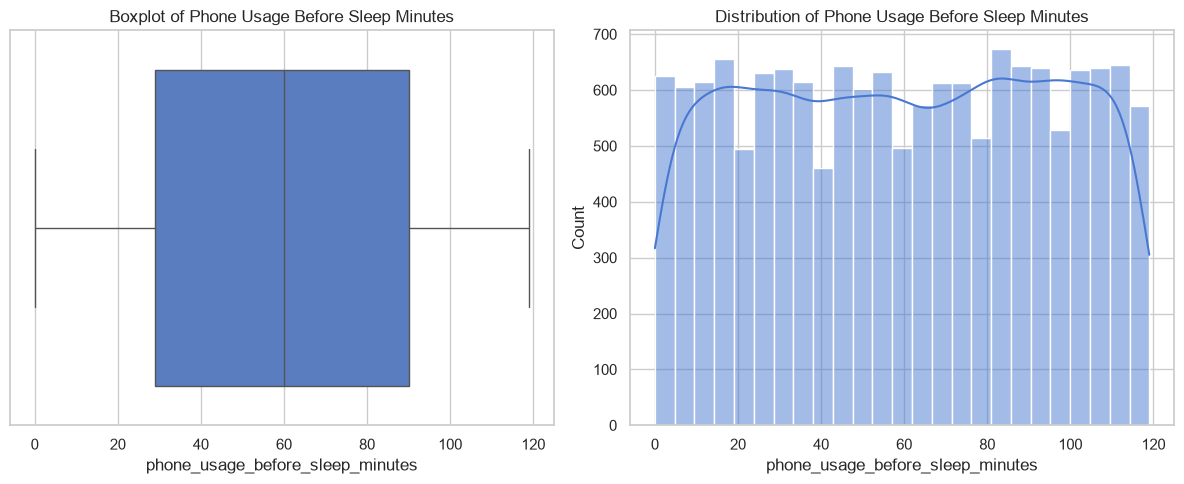

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Side 1: Boxplot
sns.boxplot(data=df, x='phone_usage_before_sleep_minutes', ax=axes[0])
axes[0].set_title('Boxplot of Phone Usage Before Sleep Minutes')

# Side 2: Distribution plot
sns.histplot(data=df, x='phone_usage_before_sleep_minutes', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Phone Usage Before Sleep Minutes')
plt.tight_layout()
plt.show()

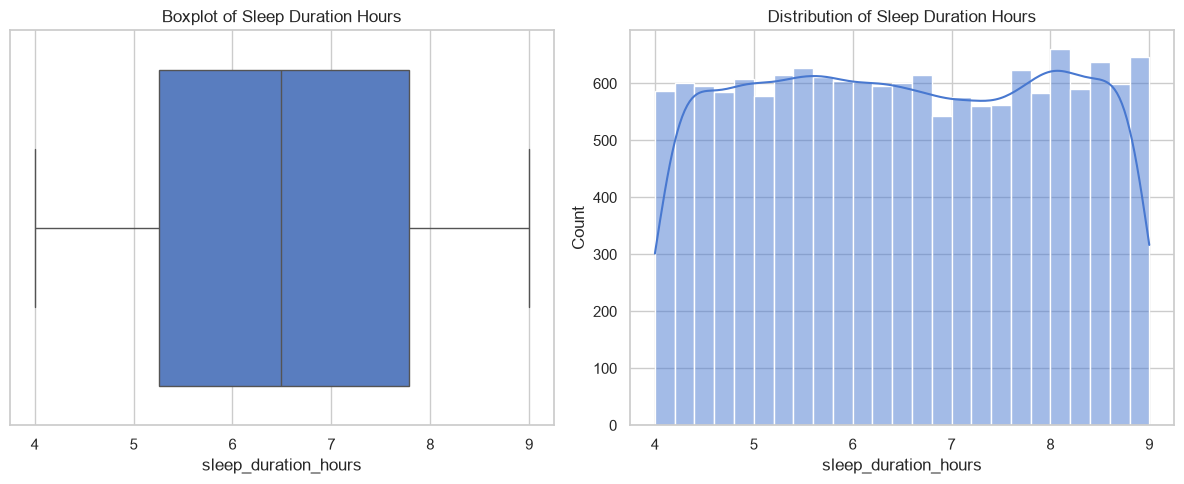

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Side 1: Boxplot
sns.boxplot(data=df, x='sleep_duration_hours', ax=axes[0])
axes[0].set_title('Boxplot of Sleep Duration Hours')

# Side 2: Distribution plot
sns.histplot(data=df, x='sleep_duration_hours', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Sleep Duration Hours')
plt.tight_layout()
plt.show()

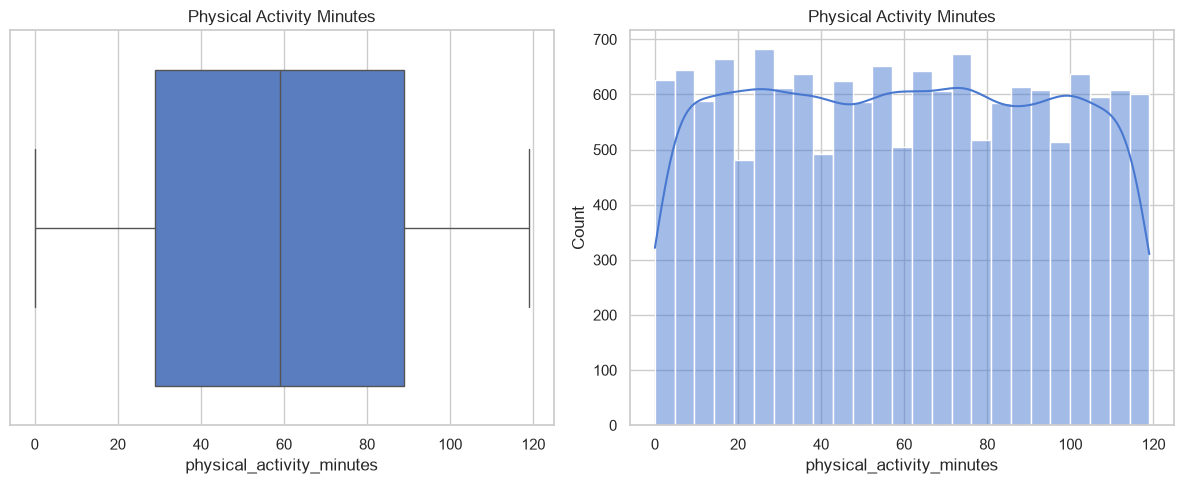

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Side 1: Boxplot
sns.boxplot(data=df, x='physical_activity_minutes', ax=axes[0])
axes[0].set_title('Physical Activity Minutes')

# Side 2: Distribution plot
sns.histplot(data=df, x='physical_activity_minutes', kde=True, ax=axes[1])
axes[1].set_title('Physical Activity Minutes')
plt.tight_layout()
plt.show()

In [34]:
def count_iqr_outliers(df, cols):
    results = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        results[col] = len(outliers)
    return results

numerical_cols = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'physical_activity_minutes'
]

count_iqr_outliers(df, numerical_cols)

{'age': 0,
 'daily_screen_time_hours': 0,
 'phone_usage_before_sleep_minutes': 0,
 'sleep_duration_hours': 0,
 'physical_activity_minutes': 0}

### Distribution & Outlier Analysis

* **Observation:** The boxplots and distribution plots for all numerical features show zero data points falling outside the calculated whisker boundaries. 
* **Distribution Shape:** The features exhibit a well-distributed, non-skewed ("wave-like") pattern, indicating a balanced spread of data across the entire range.
* **Conclusion:** There are **no statistical outliers** present in the numerical columns. 
